In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: paddy-disease-classification/train_images/hispa/104947.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104955.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104959.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104960.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104967.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104969.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104973.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104976.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104979.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104981.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104985.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104986.jpg  
  inflating: paddy-disease-classification/train_images/hispa/

In [3]:
!pip install keras-tuner --upgrade --quiet

import os

# --- Core Deep Learning (Building, Training, Tuning) ---
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt

# --- Data Handling & Math ---
import numpy as np

# --- Plotting & Analysis ---
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- Final Model Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.3 MB/s eta 0:00:00


In [4]:
dataset_path = "/content/paddy-disease-classification"
train_path = os.path.join(dataset_path, "train_images")
test_path = os.path.join(dataset_path, "test_images")

print("Train Path:", train_path)
print("Test Path:", test_path)

Train Path: /content/paddy-disease-classification/train_images
Test Path: /content/paddy-disease-classification/test_images


In [5]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
CHANNELS = 3

In [6]:
def analyze_dataset_structure(dataset_dir):
    classes = []
    class_counts = {}

    for class_folder in os.listdir(dataset_dir):
        class_path = os.path.join(dataset_dir, class_folder)
        if os.path.isdir(class_path):
            classes.append(class_folder)
            class_counts[class_folder] = len(os.listdir(class_path))

    print(f" Dataset: {dataset_dir}")
    print(f"Number of classes: {len(classes)}")
    print("Class distribution:")
    for class_name, count in class_counts.items():
        print(f" - {class_name}: {count} images")

    return classes, class_counts

# Run for training and test sets
train_classes, train_counts = analyze_dataset_structure(train_path)
test_classes, test_counts   = analyze_dataset_structure(test_path)

 Dataset: /content/paddy-disease-classification/train_images
Number of classes: 10
Class distribution:
 - downy_mildew: 1944 images
 - normal: 1872 images
 - bacterial_leaf_blight: 1916 images
 - bacterial_leaf_streak: 1900 images
 - tungro: 1936 images
 - dead_heart: 1910 images
 - bacterial_panicle_blight: 1863 images
 - hispa: 1942 images
 - blast: 1918 images
 - brown_spot: 1930 images
 Dataset: /content/paddy-disease-classification/test_images
Number of classes: 10
Class distribution:
 - downy_mildew: 620 images
 - normal: 1764 images
 - bacterial_leaf_blight: 478 images
 - bacterial_leaf_streak: 380 images
 - tungro: 1088 images
 - dead_heart: 1442 images
 - bacterial_panicle_blight: 337 images
 - hispa: 1594 images
 - blast: 1738 images
 - brown_spot: 965 images


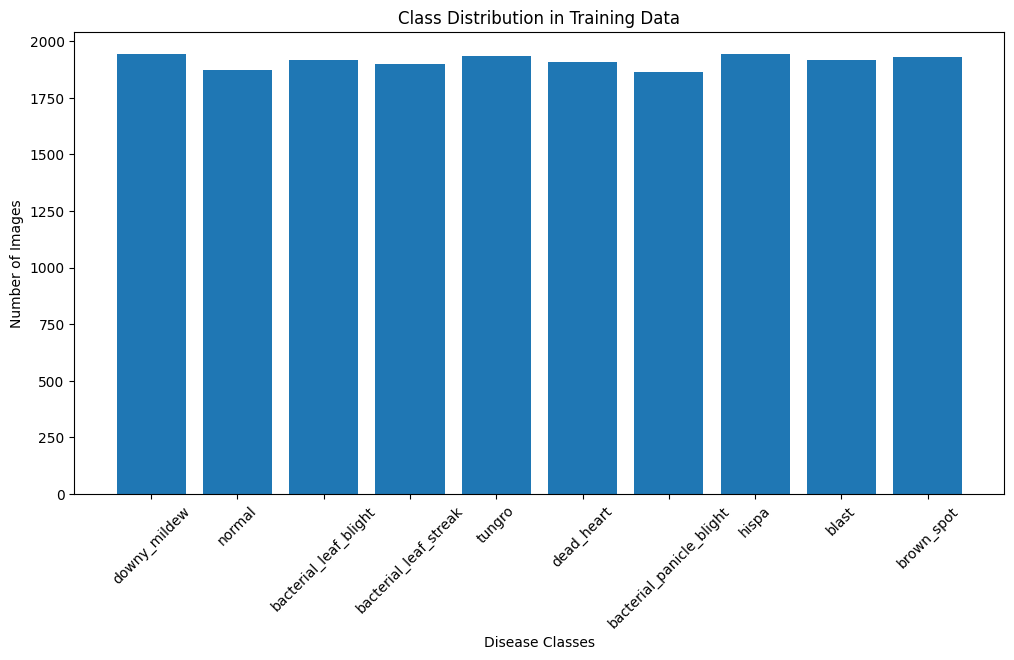

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Class Distribution in Training Data")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'downy_mildew'),
  Text(1, 0, 'normal'),
  Text(2, 0, 'bacterial_leaf_blight'),
  Text(3, 0, 'bacterial_leaf_streak'),
  Text(4, 0, 'tungro'),
  Text(5, 0, 'dead_heart'),
  Text(6, 0, 'bacterial_panicle_blight'),
  Text(7, 0, 'hispa'),
  Text(8, 0, 'blast'),
  Text(9, 0, 'brown_spot')])

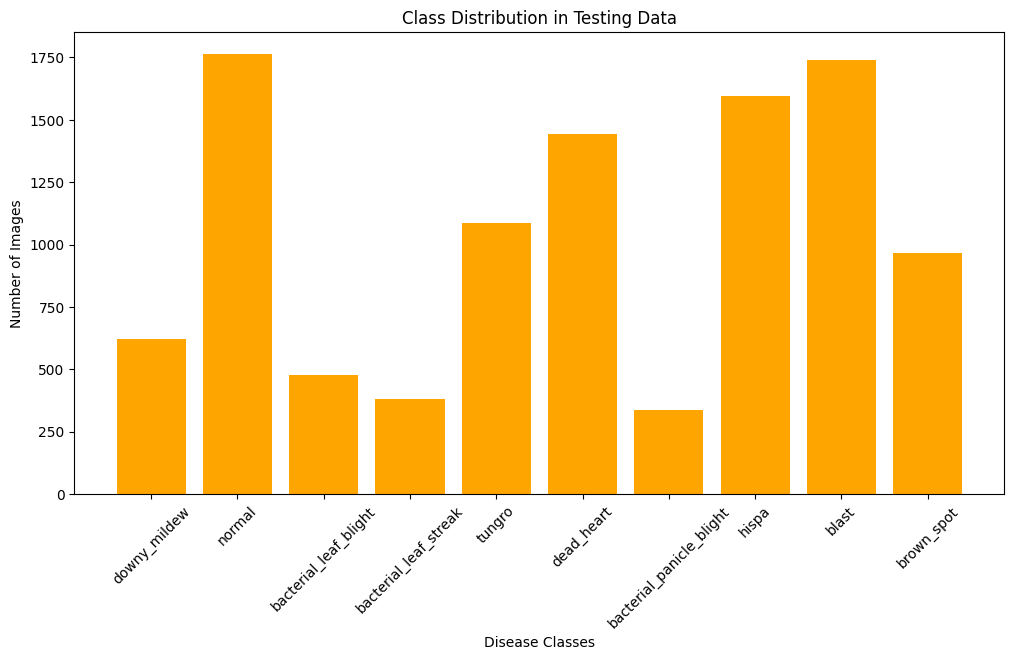

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(test_counts.keys(), test_counts.values(), color="orange")
plt.title("Class Distribution in Testing Data")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)


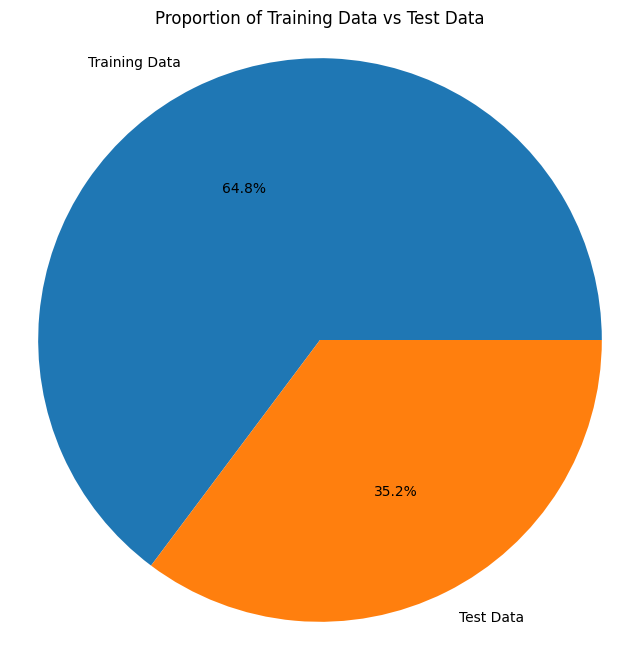

In [9]:
total_train_images = sum(train_counts.values())
total_test_images = sum(test_counts.values())

labels = ['Training Data', 'Test Data']
sizes = [total_train_images, total_test_images]
colors = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=0)
plt.title("Proportion of Training Data vs Test Data")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [10]:
dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)
class_names = dataset.class_names
NUM_CLASSES = len(class_names)  # <-- THIS LINE HERE
print(f"Found {NUM_CLASSES} classes: {class_names}")

Found 19131 files belonging to 10 classes.
Found 10 classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [11]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1,
                              shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [12]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)
print("Full dataset split (80/10/10):")
print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")

Full dataset split (80/10/10):
Train batches: 478
Validation batches: 59
Test batches: 61


In [13]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [14]:
labels = ['Training Data', 'Validation Data', 'Test Data']
sizes = [len(train_ds), len(val_ds), len(test_ds)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

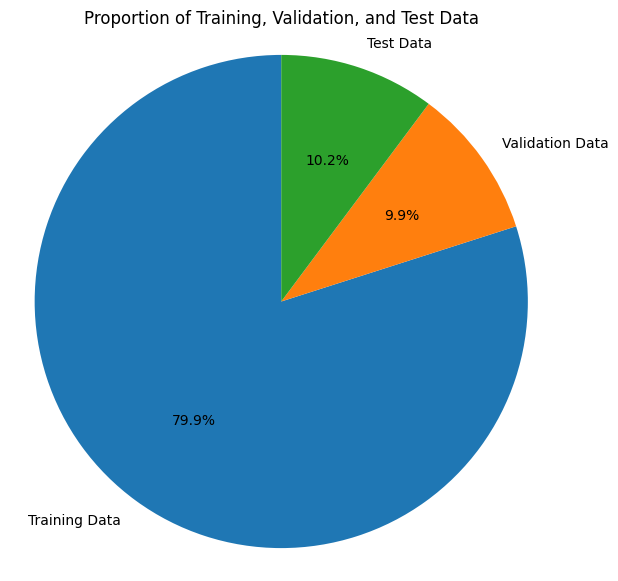

In [15]:
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Proportion of Training, Validation, and Test Data")
plt.axis('equal')
plt.show()

In [16]:
# 1. Create the small "tuning" dataset (approx 15% of data)
tune_ds = train_ds.take(len(train_ds) // 5) # Use 1/5th of the 80%
tune_ds = tune_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Create a small "tuning validation" set (approx 5% of data)
tune_val_ds = val_ds.take(len(val_ds) // 2) # Use 1/2 of the 10%
tune_val_ds = tune_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Created small tuning dataset with {len(tune_ds)} batches.")
print(f"Created small tuning validation set with {len(tune_val_ds)} batches.")

Created small tuning dataset with 95 batches.
Created small tuning validation set with 29 batches.


In [17]:
resize_and_scale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])

In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
], name="data_augmentation")

In [19]:
def build_model(hp):

    # --- 1. Tune Hyperparameters ---
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])
    hp_dense_units = hp.Choice('dense_units', values=[128, 256])
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    hp_filters_3 = hp.Choice('filters_3', values=[64, 128])
    hp_filters_4 = hp.Choice('filters_4', values=[128, 256])

    # --- 2. Build the Model ---
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

        # Preprocessing layers
        # Note: resize_and_scale is not needed here,
        # as image_dataset_from_directory already resized and we can add Rescaling here.
        layers.Rescaling(1./255),
        data_augmentation,

        # --- Block 1 (Static) ---
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # --- Block 2 (Static) ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # --- Block 3 (Tunable) ---
        layers.Conv2D(hp_filters_3, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # --- Block 4 (Tunable) ---
        layers.Conv2D(hp_filters_4, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # --- Classifier Head (Tunable) ---
        layers.Flatten(),
        layers.Dense(hp_dense_units, activation='relu'),
        layers.Dropout(hp_dropout),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    # --- 3. Compile the Model ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [20]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,  # Try 5 different combinations
    executions_per_trial=1, # Train each combination once
    directory='my_tuner_dir',
    project_name='paddy_disease_tuning'
)

In [21]:
print("Starting LIGHTWEIGHT hyperparameter search on SMALL dataset...")
tuner.search(
    tune_ds,          # <-- Use the SMALL tuning set
    epochs=5,         # <-- Use few epochs
    validation_data=tune_val_ds  # <-- Use the SMALL validation set
)

Trial 5 Complete [00h 00m 29s]
val_accuracy: 0.1681034415960312

Best val_accuracy So Far: 0.35668104887008667
Total elapsed time: 00h 04m 35s


In [22]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n--- Search Complete! ---")
print(f"Best learning rate: {best_hps.get('learning_rate')}")
print(f"Best dense units: {best_hps.get('dense_units')}")
print(f"Best dropout rate: {best_hps.get('dropout')}")
print(f"Best filters (Block 3): {best_hps.get('filters_3')}")
print(f"Best filters (Block 4): {best_hps.get('filters_4')}")


--- Search Complete! ---
Best learning rate: 0.0001
Best dense units: 256
Best dropout rate: 0.2
Best filters (Block 3): 128
Best filters (Block 4): 128



--- Analyzing Tuning Results ---
Hyperparameter Tuning Results Table:
   learning_rate  dense_units  dropout  filters_3  filters_4 trial_id  \
1         0.0001          256      0.2        128        128        1   
0         0.0001          128      0.2         64        128        0   
2         0.0010          128      0.3         64        128        2   
3         0.0010          256      0.3         64        256        3   
4         0.0010          256      0.3        128        256        4   

   val_accuracy  
1      0.356681  
0      0.313578  
2      0.202586  
3      0.181034  
4      0.168103  


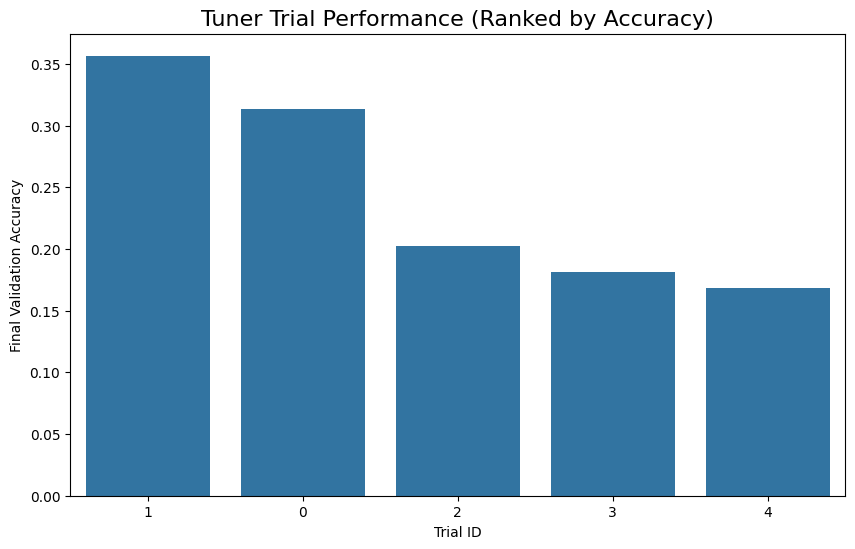

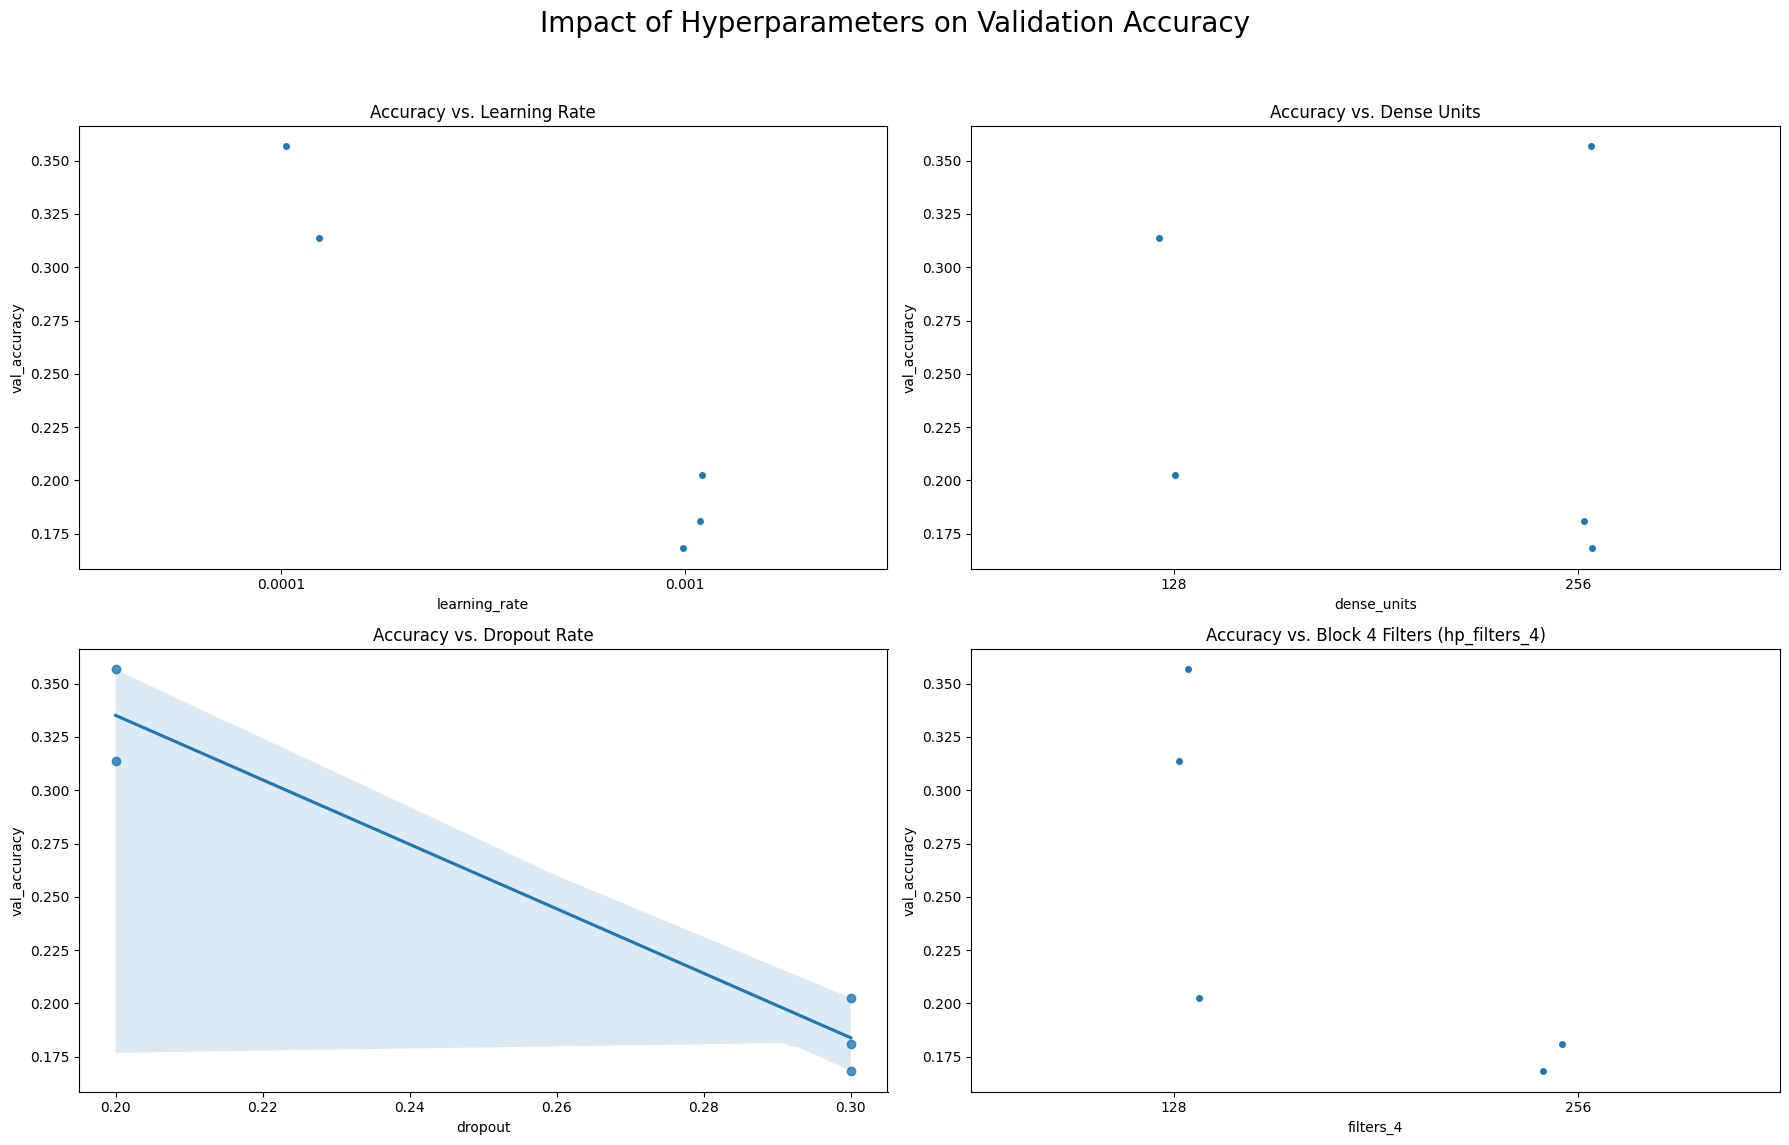

In [23]:
print("\n--- Analyzing Tuning Results ---")

# Get all the trials
all_trials = tuner.oracle.trials
results = []
for trial_id, trial in all_trials.items():
    if trial.status == 'COMPLETED':
        hps = trial.hyperparameters.values
        score = trial.score
        trial_data = hps.copy()
        trial_data['trial_id'] = trial.trial_id
        trial_data['val_accuracy'] = score
        results.append(trial_data)

# Create a Pandas DataFrame
results_df = pd.DataFrame(results).sort_values(by='val_accuracy', ascending=False)

# --- 1. The Comparison Table ---
print("Hyperparameter Tuning Results Table:")
print(results_df)

# --- 2. Bar Plot: Ranking of All Trials ---
plt.figure(figsize=(10, 6))
sns.barplot(x='trial_id', y='val_accuracy', data=results_df, order=results_df['trial_id'])
plt.title('Tuner Trial Performance (Ranked by Accuracy)', fontsize=16)
plt.xlabel('Trial ID')
plt.ylabel('Final Validation Accuracy')
plt.show()

# --- 3. Hyperparameter Impact Plots ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Impact of Hyperparameters on Validation Accuracy', fontsize=20)
sns.stripplot(ax=axes[0, 0], x='learning_rate', y='val_accuracy', data=results_df)
axes[0, 0].set_title('Accuracy vs. Learning Rate')
sns.stripplot(ax=axes[0, 1], x='dense_units', y='val_accuracy', data=results_df)
axes[0, 1].set_title('Accuracy vs. Dense Units')
sns.regplot(ax=axes[1, 0], x='dropout', y='val_accuracy', data=results_df)
axes[1, 0].set_title('Accuracy vs. Dropout Rate')
sns.stripplot(ax=axes[1, 1], x='filters_4', y='val_accuracy', data=results_df)
axes[1, 1].set_title('Accuracy vs. Block 4 Filters (hp_filters_4)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [25]:
model = tuner.hypermodel.build(best_hps)
print("\n--- Final Model Summary ---")
model.summary()


# This rule monitors 'val_loss' with a patience of 3
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# 2. Train this final model on the FULL, ORIGINAL datasets
EPOCHS = 30

print(f"\nStarting final model training for {EPOCHS} epochs on FULL dataset...")
history = model.fit(
    train_ds,          # <-- Use the FULL 80% dataset
    validation_data=val_ds,  # <-- Use the FULL 10% dataset
    epochs=EPOCHS,
    callbacks=[early_stop]
)
print("Final training complete!")


--- Final Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,342,218 (8.93 MB)

 Trainable params: 2,341,514 (8.93 MB)

 Non-trainable params: 704 (2.75 KB)


Starting final model training for 30 epochs on FULL dataset...
Epoch 1/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 129s 150ms/step - accuracy: 0.2599 - loss: 2.2417 - val_accuracy: 0.2765 - val_loss: 2.2359
Epoch 2/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4167 - loss: 1.6731 - val_accuracy: 0.4311 - val_loss: 1.5939
Epoch 3/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.5147 - loss: 1.3960 - val_accuracy: 0.5222 - val_loss: 1.3547
Epoch 4/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.5703 - loss: 1.2251 - val_accuracy: 0.5090 - val_loss: 1.3960
Epoch 5/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.6329 - loss: 1.0776 - val_accuracy: 0.5779 - val_loss: 1.1691
Epoch 6/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.6736 - loss: 0.9477 - val_accuracy: 0.6329 - val_loss: 1.0348
Epoch 7/30
478/478 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.7012 - loss: 0.8572 - val_accuracy: 0.6817 - val_loss: 0.9131
Epoch 8/30
478/478 ━━━━━


Plotting final model accuracy and loss...


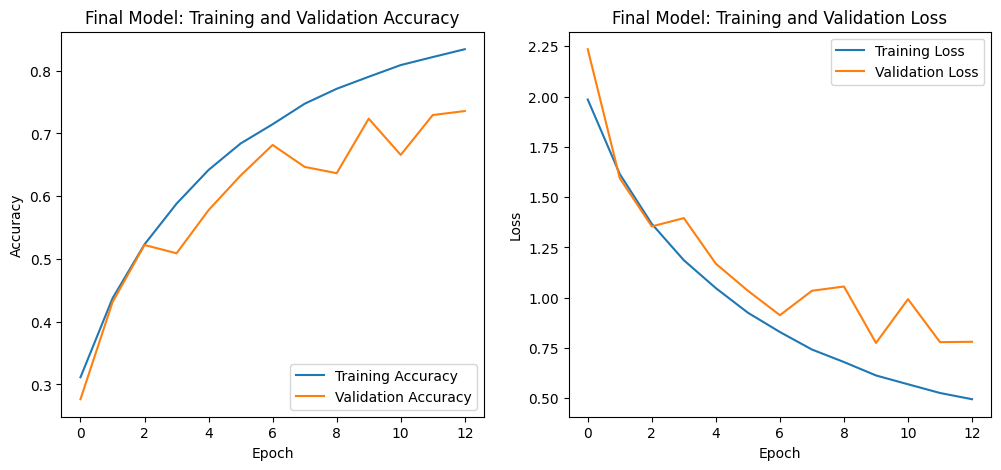

In [26]:
# ----------------------------------------------------------------------
# CELL 17: PLOT FINAL MODEL'S TRAINING HISTORY
# ----------------------------------------------------------------------

print("\nPlotting final model accuracy and loss...")

# Get the data from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs that *actually* ran
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# --- Plot Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Final Model: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Final Model: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [27]:
# ----------------------------------------------------------------------
# CELL 18: EVALUATE ON TEST SET
# ----------------------------------------------------------------------
print("\nEvaluating final model on the unseen test dataset...")
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Evaluating final model on the unseen test dataset...
61/61 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - accuracy: 0.7246 - loss: 0.8072

Test Loss: 0.7967016696929932
Test Accuracy: 72.69%



Generating Confusion Matrix and Classification Report...
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


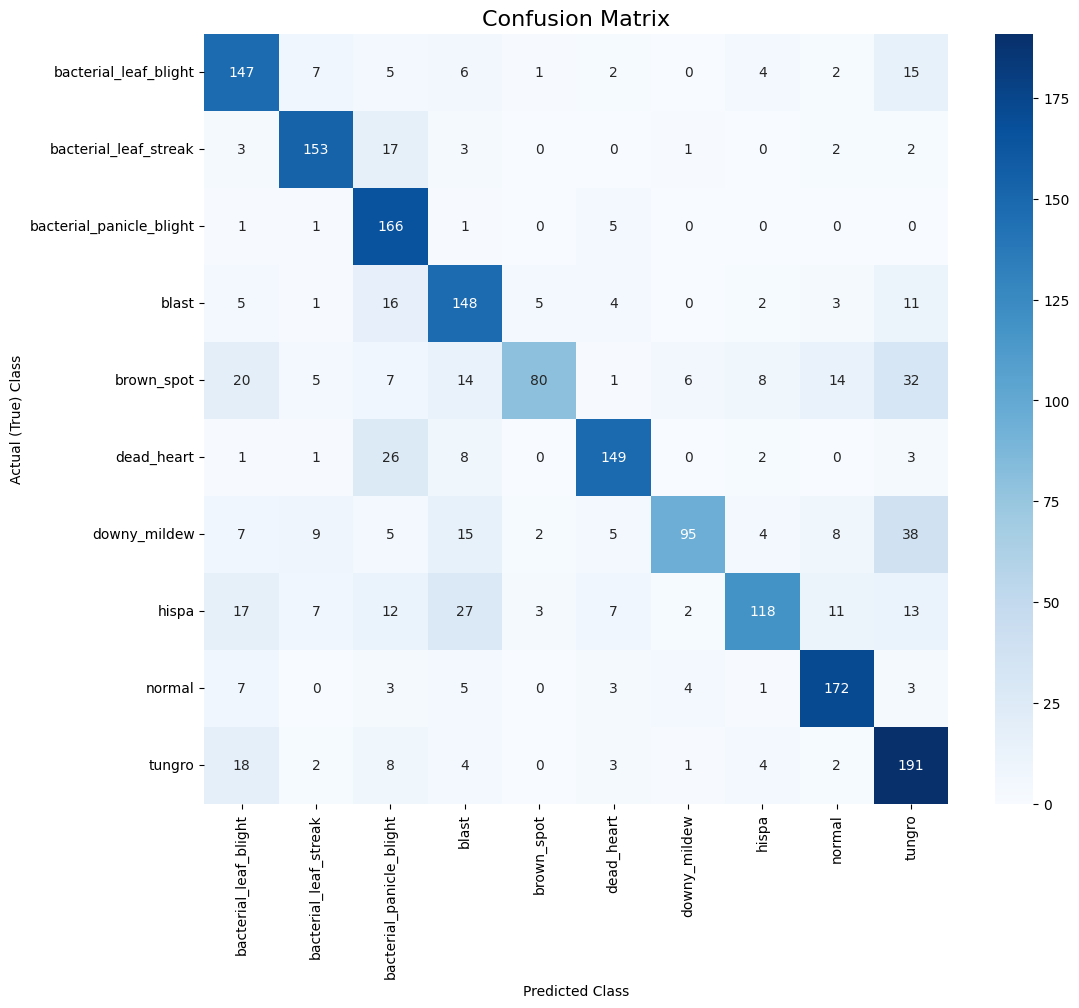


Classification Report:

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.65      0.78      0.71       189
   bacterial_leaf_streak       0.82      0.85      0.83       181
bacterial_panicle_blight       0.63      0.95      0.76       174
                   blast       0.64      0.76      0.69       195
              brown_spot       0.88      0.43      0.58       187
              dead_heart       0.83      0.78      0.81       190
            downy_mildew       0.87      0.51      0.64       188
                   hispa       0.83      0.54      0.66       217
                  normal       0.80      0.87      0.83       198
                  tungro       0.62      0.82      0.71       233

                accuracy                           0.73      1952
               macro avg       0.76      0.73      0.72      1952
            weighted avg       0.76      0.73      0.72      1952



In [28]:
# ----------------------------------------------------------------------
# CELL 19: CONFUSION MATRIX & CLASSIFICATION REPORT
# ----------------------------------------------------------------------
print("\nGenerating Confusion Matrix and Classification Report...")

# 1. Get the true labels from the test dataset
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 2. Get the model's predictions
predictions_prob = model.predict(test_ds)

# 3. Convert probabilities to class labels
y_pred = np.argmax(predictions_prob, axis=1)

# 4. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',  # Format annotations as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual (True) Class')
plt.xlabel('Predicted Class')
plt.show()

# 6. Print a detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Visualizing model predictions on a batch of test images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


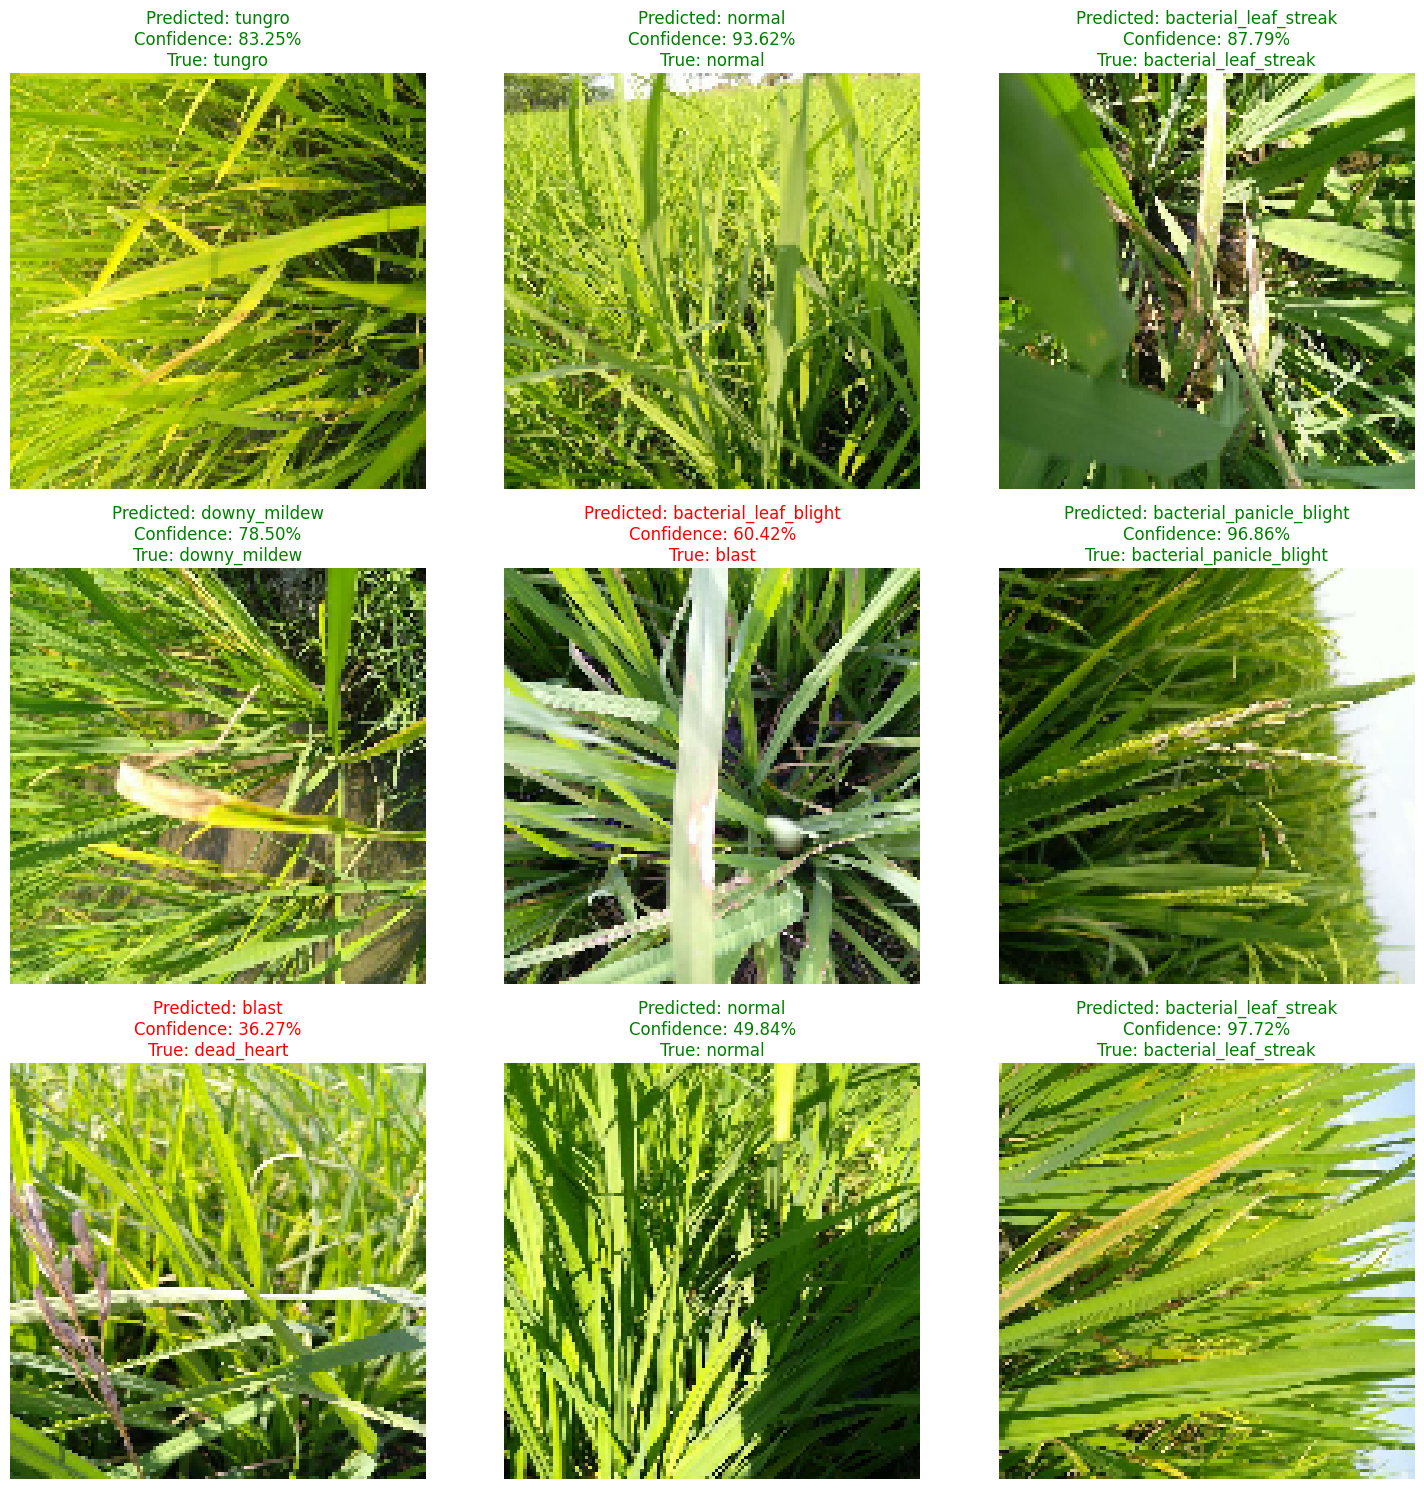

In [29]:
# ----------------------------------------------------------------------
# CELL 20: VISUALIZE PREDICTIONS ON TEST IMAGES
# ----------------------------------------------------------------------
print("\nVisualizing model predictions on a batch of test images...")

# 1. Get one batch of test images and labels
image_batch, label_batch = next(iter(test_ds))
image_batch_for_pred = image_batch.numpy()
label_batch_true = label_batch.numpy()

# 2. Get the model's predictions (probabilities)
predictions_prob = model.predict(image_batch_for_pred)

# 3. Get the predicted class index and confidence
y_pred_indices = np.argmax(predictions_prob, axis=1)
confidence_scores = np.max(predictions_prob, axis=1) * 100

# 4. Plot the first 9 images
plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i + 1)

    # We need to rescale the image from [0,1] to [0,255] for plotting
    # or just plot it as-is if it's already scaled (which it is, but matplotlib handles it)
    # The images in image_batch are already rescaled by the model's Rescaling(1./255)
    # To plot them correctly, we should use the *original* images.
    # Let's re-load a batch *without* the rescaling for plotting

    # Re-get a batch from the original 'test_ds' which has not had rescaling applied yet
    # Note: test_ds images are (0-255)
    img_plot = image_batch[i].numpy().astype("uint8") # Convert to integer for plotting
    true_label_index = label_batch_true[i]
    predicted_label_index = y_pred_indices[i]
    confidence = confidence_scores[i]

    plt.imshow(img_plot)
    plt.axis('off')

    # Set the title color
    color = "green" if predicted_label_index == true_label_index else "red"

    # Create the title
    plt.title(
        f"Predicted: {class_names[predicted_label_index]}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"True: {class_names[true_label_index]}",
        color=color,
        fontsize=12
    )

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step


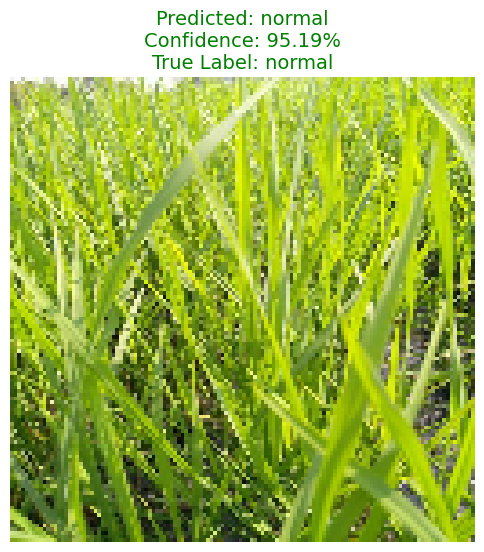

In [30]:
# ----------------------------------------------------------------------
# CELL 21: PREDICT ON A SINGLE RANDOM TEST IMAGE
# ----------------------------------------------------------------------

# 1. Get one batch of test images and labels
image_batch, label_batch = next(iter(test_ds))
image_batch_numpy = image_batch.numpy()
label_batch_numpy = label_batch.numpy()

# 2. Pick a random image from that batch
import random
random_index = random.randint(0, len(image_batch_numpy) - 1)

# 3. Get the single image and its true label
img_to_predict = image_batch_numpy[random_index]
true_label_index = label_batch_numpy[random_index]
true_label_name = class_names[true_label_index]

# 4. Prepare the image for the model
# We need to add a "batch" dimension, making its shape (1, 120, 120, 3)
img_for_prediction = np.expand_dims(img_to_predict, axis=0)

# 5. Get the model's prediction
prediction_probs = model.predict(img_for_prediction)
predicted_label_index = np.argmax(prediction_probs)
predicted_label_name = class_names[predicted_label_index]
confidence = np.max(prediction_probs) * 100

# 6. Display the image and the result
plt.figure(figsize=(6, 7))
plt.imshow(img_to_predict.astype("uint8")) # Plot the original image
plt.axis('off')

# Set the title color
color = "green" if predicted_label_index == true_label_index else "red"

# Create the title
plt.title(
    f"Predicted: {predicted_label_name}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"True Label: {true_label_name}",
    color=color,
    fontsize=14
)

plt.show()